In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
from renormalizer.mps import Mpo, Mps, gs
from renormalizer.utils import OptimizeConfig, Quantity, constant

NOTEBOOK_DIR = Path.cwd().resolve()
DATA_ROOT = NOTEBOOK_DIR.parent
MODEL_NAME = DATA_ROOT.name.lower()
FILE_PREFIX = {"dimer": "Dimer", "trimer": "Trimer", "hexamer": "Hexamer"}[MODEL_NAME]
DISPLAY_NAME = FILE_PREFIX.lower()
PBI_FT_ROOT = NOTEBOOK_DIR.parents[1]
if str(PBI_FT_ROOT) not in sys.path:
    sys.path.insert(0, str(PBI_FT_ROOT))

from pbi_model import construct_pbi_model

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CARRIER_RE = re.compile(r"subtracts excited-state carrier energy ([0-9.eE+-]+) au")


def model_zpe_ha(model):
    if hasattr(model, "gs_zpe"):
        return float(model.gs_zpe)
    return sum(0.5 * float(ph.omega[0]) for mol in model.mol_list for ph in mol.ph_list)


def zero_t_one_exciton_energy_ha(model):
    opt = OptimizeConfig()
    np.random.seed(0)
    h_mpo = Mpo(model, offset=Quantity(0))
    i_mps = Mps.random(model, 1, opt.procedure[0][0], 1)
    i_mps.optimize_config = opt
    energies, _ = gs.optimize_mps(i_mps, h_mpo)
    return float(np.min(energies))


def is_multiset_spectrum(path):
    return "multiset" in Path(path).parts


def log_carrier_energy_ha(path):
    log_path = Path(path).with_suffix(".log")
    if not log_path.exists():
        return 0.0
    text = log_path.read_text(errors="ignore")
    matches = CARRIER_RE.findall(text)
    return float(matches[-1]) if matches else 0.0


def saved_carrier_energy_ha(path, data=None):
    if data is not None and "carrier_energy" in data.files:
        return float(np.asarray(data["carrier_energy"]))
    return log_carrier_energy_ha(path)


model = construct_pbi_model(MODEL_NAME)
ZERO_EXCITON_ZPE_HA = model_zpe_ha(model)
ABS_PHASE_HA = ZERO_EXCITON_ZPE_HA
ONE_EXCITON_MIN_HA = zero_t_one_exciton_energy_ha(model)
E00_HA = ONE_EXCITON_MIN_HA - ZERO_EXCITON_ZPE_HA
# Strict finite-T emission phase: E00 + zero-exciton ZPE = E_EX,0.
# E_EX,0 is obtained from the same dimer Holstein model by zero-T DMRG.
EMI_MODEL_PHASE_HA = E00_HA + ZERO_EXCITON_ZPE_HA
print(f"Model = {MODEL_NAME}")
print(f"Zero-exciton ZPE = {ZERO_EXCITON_ZPE_HA:.10f} Ha = {ZERO_EXCITON_ZPE_HA * constant.au2ev:.9f} eV = {ZERO_EXCITON_ZPE_HA * constant.au2cm:.3f} cm^-1")
print(f"Zero-T one-exciton minimum E_EX,0 = {ONE_EXCITON_MIN_HA:.10f} Ha = {ONE_EXCITON_MIN_HA * constant.au2ev:.9f} eV = {ONE_EXCITON_MIN_HA * constant.au2cm:.3f} cm^-1")
print(f"Model-derived E00 = {E00_HA:.10f} Ha = {E00_HA * constant.au2ev:.9f} eV = {E00_HA * constant.au2cm:.3f} cm^-1")
print(f"Emission phase E00 + ZPE = {EMI_MODEL_PHASE_HA:.10f} Ha = {EMI_MODEL_PHASE_HA * constant.au2ev:.9f} eV = {EMI_MODEL_PHASE_HA * constant.au2cm:.3f} cm^-1")


2026-07-06 16:31:46,883[INFO] Using GPU: 0
2026-07-06 16:31:46,909[INFO] Use CuPy as backend
2026-07-06 16:31:46,910[INFO] cupy random seed is 2019
2026-07-06 16:31:46,910[INFO] random seed is 1092
2026-07-06 16:31:46,976[INFO] Git Commit Hash: a938bf00dd4e0c4f2b01eeac7ddfc0ca9c60b339
2026-07-06 16:31:46,980[INFO] use 64 bits
2026-07-06 16:31:48,974[DEBUG] # of operator terms: 64
2026-07-06 16:31:48,976[DEBUG] Input operator terms: 64
2026-07-06 16:31:49,031[DEBUG] After combination of the same terms: 64
2026-07-06 16:31:49,032[DEBUG] symbolic mpo algorithm: qr
2026-07-06 16:31:50,346[INFO] optimization method: 2site
2026-07-06 16:31:50,347[INFO] e_rtol: 1e-06
2026-07-06 16:31:50,348[INFO] e_atol: 1e-08
2026-07-06 16:31:50,348[INFO] procedure: [[10, 0.4], [20, 0.2], [30, 0.1], [40, 0], [40, 0]]
2026-07-06 16:31:50,505[DEBUG] isweep: 0
2026-07-06 16:31:50,507[DEBUG] compress config in current loop: 10, percent: 0.4
2026-07-06 16:31:50,508[DEBUG] mps current size: 45.7KiB, Matrix product

Model = dimer
Zero-exciton ZPE = 0.0438456141 Ha = 1.193099942 eV = 9623.000 cm^-1
Zero-T one-exciton minimum E_EX,0 = 0.1205399601 Ha = 3.280059412 eV = 26455.463 cm^-1
Model-derived E00 = 0.0766943460 Ha = 2.086959471 eV = 16832.463 cm^-1
Emission phase E00 + ZPE = 0.1205399601 Ha = 3.280059412 eV = 26455.463 cm^-1


In [2]:
def load_time(data):
    return np.asarray(data["time_series" if "time_series" in data.files else "time series"], dtype=float)


def autocorr_to_intensity(path, spectratype):
    data = np.load(path, allow_pickle=True)
    time_au = load_time(data)
    corr = np.asarray(data["autocorr"], dtype=np.complex128)
    if len(corr) < 100 or len(time_au) != len(corr):
        raise ValueError(f"incomplete autocorr: {len(corr)} time points")
    tau_au = time_au - time_au[0]
    dt_au = time_au[1] - time_au[0]

    if spectratype == "emi":
        # Renormalizer stores finite-T emission autocorr with an extra
        # conjugation (BraKetPairEmiFiniteT / MultisetSpectraFiniteT).
        # Convert it back before applying the zero-exciton ZPE phase.
        if is_multiset_spectrum(path):
            # Multiset finite-T emission subtracts a carrier during runtime;
            # undo that saved offset before undoing the stored conjugation.
            corr = corr * np.exp(1j * saved_carrier_energy_ha(path, data) * tau_au)
        corr = np.conjugate(corr)
        phase_energy_ha = ZERO_EXCITON_ZPE_HA
    else:
        phase_energy_ha = ABS_PHASE_HA
    corr = corr * np.exp(1j * phase_energy_ha * tau_au)

    fft_freq_au = np.fft.fftfreq(len(corr), d=dt_au) * 2.0 * np.pi
    freq_au = -fft_freq_au
    intensity = np.abs(np.fft.fft(corr))

    keep = freq_au > 0
    wavelength_nm = 1e7 / (freq_au[keep] * constant.au2cm)
    intensity = intensity[keep]
    if spectratype == "emi":
        intensity = intensity * freq_au[keep] ** 3
    else:
        intensity = intensity * freq_au[keep]
    intensity = intensity / intensity.max()
    order = np.argsort(wavelength_nm)
    return wavelength_nm[order], intensity[order]


def plot_specs(specs, spectratype, title, outfile):
    curves = []
    skipped = []
    for spec in specs:
        try:
            x, y = autocorr_to_intensity(spec["path"], spectratype)
        except Exception as exc:
            skipped.append(f'{spec["label"]}: {spec["path"].name} ({type(exc).__name__}: {exc})')
            continue
        curves.append((spec, x, y))
    if skipped:
        print("Skipped unreadable spectra:")
        for item in skipped:
            print(f"  {item}")
    if not curves:
        raise ValueError(f"No readable {spectratype} spectra were found.")

    main_xlim = (350, 750)
    peak_nm, peak_y = None, -np.inf
    for _, x, y in curves:
        mask = (x >= main_xlim[0]) & (x <= main_xlim[1])
        if np.any(mask) and np.max(y[mask]) > peak_y:
            idx = np.where(mask)[0][np.argmax(y[mask])]
            peak_nm, peak_y = x[idx], y[idx]
    zoom_xlim = (max(main_xlim[0], peak_nm - 100), min(main_xlim[1], peak_nm + 100))

    fig, (ax, ax_zoom) = plt.subplots(
        1, 2, figsize=(12.2, 4.8), gridspec_kw={"width_ratios": [2.35, 1.0]}, constrained_layout=True
    )
    for spec, x, y in curves:
        for target in (ax, ax_zoom):
            target.plot(x, y, label=spec["label"], color=spec["color"], linestyle=spec["ls"], linewidth=2.0)

    ax.set_xlim(*main_xlim)
    ax_zoom.set_xlim(*zoom_xlim)
    for target in (ax, ax_zoom):
        target.set_ylim(0, 1.05)
        target.set_xlabel("Wavelength (nm)")
        target.set_ylabel("Normalized intensity")
        target.grid(alpha=0.22, linewidth=0.7)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)
    ax_zoom.set_title(f"Peak +/- 100 nm ({zoom_xlim[0]:.0f}-{zoom_xlim[1]:.0f} nm)")
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()


In [3]:
STYLE = {
    ("singleset", 64): {"color": "#74a9cf", "ls": "-"},
    ("multiset", 64): {"color": "#0570b0", "ls": "--"},
    ("singleset", 128): {"color": "#fdae6b", "ls": "-"},
    ("multiset", 128): {"color": "#e6550d", "ls": "--"},
}

def spec(kind, method, chi):
    suffix = "s" if method == "singleset" else "m"
    return {
        "path": DATA_ROOT / kind / method / f"{FILE_PREFIX}_{kind}_{suffix}{chi}.npz",
        "label": f"{method.replace('set', '-set')} chi={chi}",
        **STYLE[(method, chi)],
    }

abs_specs = [spec("abs", "singleset", 64), spec("abs", "multiset", 64),
             spec("abs", "singleset", 128), spec("abs", "multiset", 128)]
emi_specs = [spec("emi", "singleset", 64), spec("emi", "multiset", 64),
             spec("emi", "singleset", 128), spec("emi", "multiset", 128)]
emi_singleset_specs = [spec("emi", "singleset", 64), spec("emi", "singleset", 128)]

missing = [str(spec["path"]) for spec in abs_specs + emi_specs if not spec["path"].exists()]
if missing:
    raise FileNotFoundError("\n".join(missing))


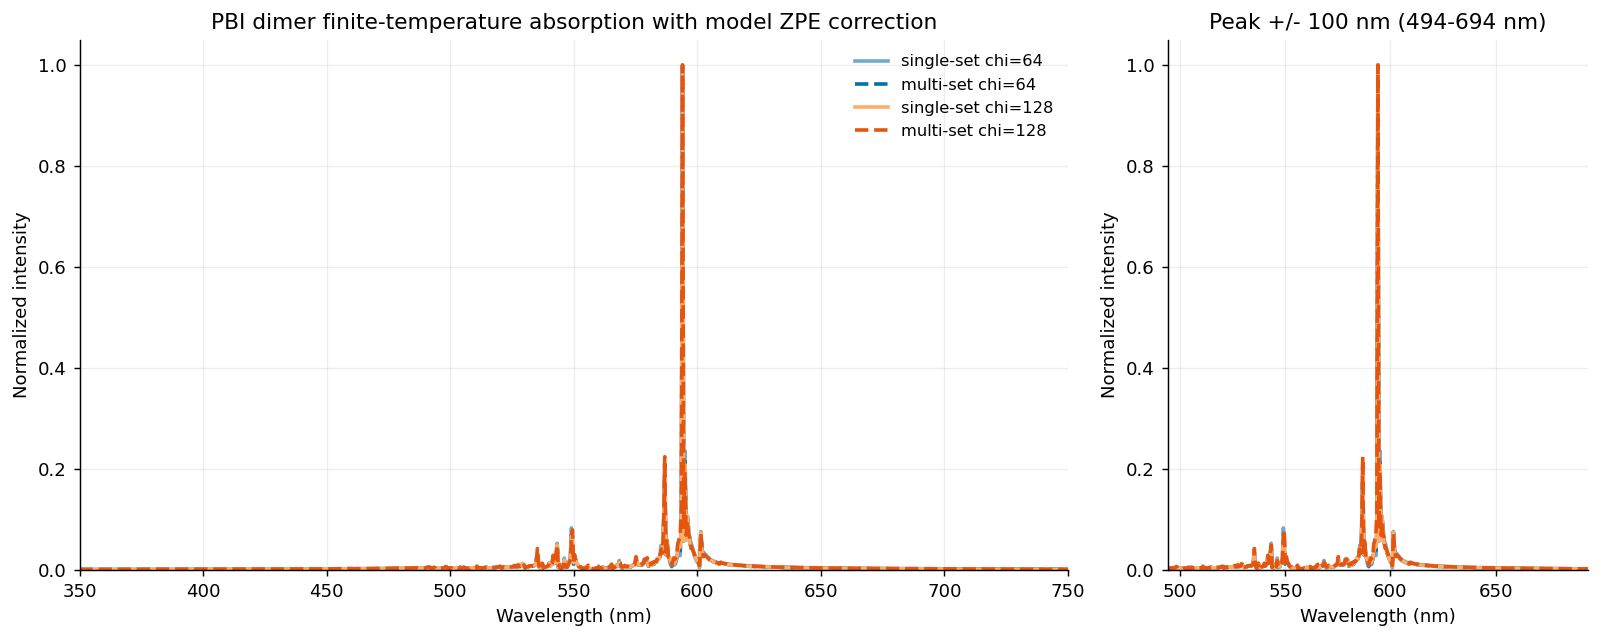

In [4]:
plot_specs(
    abs_specs,
    "abs",
    f"PBI {DISPLAY_NAME} finite-temperature absorption with model ZPE correction",
    f"{MODEL_NAME}_abs_zpe.pdf",
)


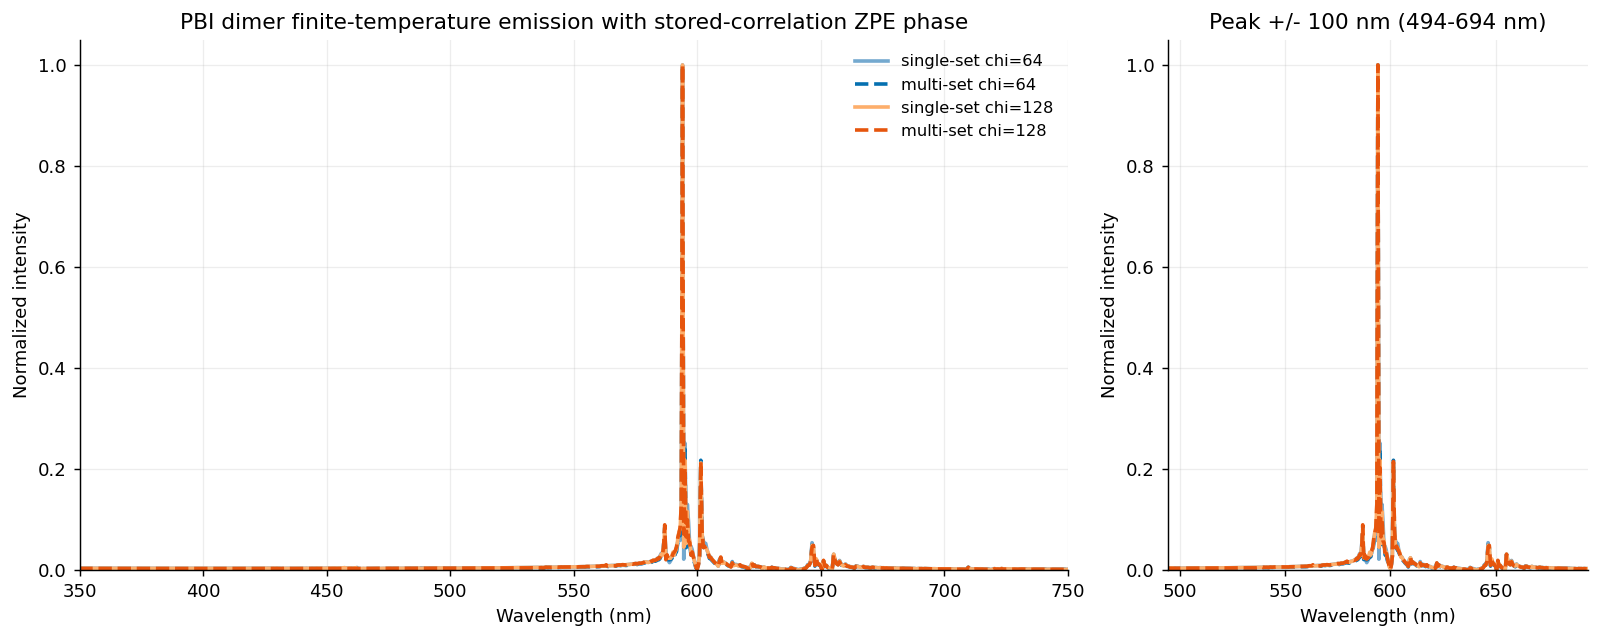

In [5]:
plot_specs(
    emi_specs,
    "emi",
    f"PBI {DISPLAY_NAME} finite-temperature emission with stored-correlation ZPE phase",
    f"{MODEL_NAME}_emi_zpe.pdf",
)


Singleset check: undo stored finite-T emission conjugation, then apply model ZPE phase
E_EX,0 diagnostic = 3.280059412 eV = 26455.463 cm^-1
E00 = E_EX,0 - ZPE = 2.086959471 eV = 16832.463 cm^-1
single-set chi=64: 350-750 nm peak = 594.028 nm, 600-630 nm window peak = 601.417 nm, relative intensity = 2.119e-01
single-set chi=128: 350-750 nm peak = 594.028 nm, 600-630 nm window peak = 601.417 nm, relative intensity = 2.123e-01


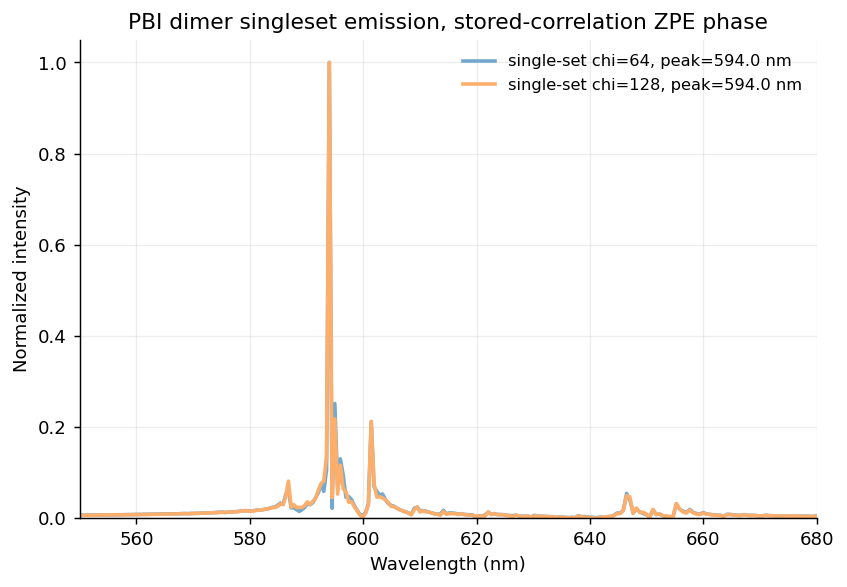

In [6]:
def peak_nm_in_window(x, y, window=(600, 630)):
    mask = (x >= window[0]) & (x <= window[1])
    idx = np.where(mask)[0][np.argmax(y[mask])]
    return float(x[idx]), float(y[idx])


fig, ax = plt.subplots(figsize=(6.4, 4.4), constrained_layout=True)
print("Singleset check: undo stored finite-T emission conjugation, then apply model ZPE phase")
print(f"E_EX,0 diagnostic = {EMI_MODEL_PHASE_HA * constant.au2ev:.9f} eV = {EMI_MODEL_PHASE_HA * constant.au2cm:.3f} cm^-1")
print(f"E00 = E_EX,0 - ZPE = {E00_HA * constant.au2ev:.9f} eV = {E00_HA * constant.au2cm:.3f} cm^-1")
for item in emi_singleset_specs:
    x, y = autocorr_to_intensity(item["path"], "emi")
    mask = (x >= 350) & (x <= 750)
    global_idx = np.where(mask)[0][np.argmax(y[mask])]
    peak_nm, peak_y = float(x[global_idx]), float(y[global_idx])
    window_nm, window_y = peak_nm_in_window(x, y)
    ax.plot(
        x,
        y,
        label=f'{item["label"]}, peak={peak_nm:.1f} nm',
        color=item["color"],
        linestyle=item["ls"],
        linewidth=2.0,
    )
    print(f'{item["label"]}: 350-750 nm peak = {peak_nm:.3f} nm, 600-630 nm window peak = {window_nm:.3f} nm, relative intensity = {window_y:.3e}')
ax.set_xlim(550, 680)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized intensity")
ax.set_title("PBI dimer singleset emission, stored-correlation ZPE phase")
ax.grid(alpha=0.22, linewidth=0.7)
ax.legend(frameon=False, fontsize=9)
fig.savefig(f"{MODEL_NAME}_emi_singleset_model_Eex0_check.pdf", bbox_inches="tight")
plt.show()
